--- Лабораторная работа № 5: Модель "хищник-жертва" (Лотки-Вольтерры) ---

In [2]:
using DifferentialEquations, Plots, LaTeXStrings

============================================================================
Модель: dx/dt = -a x + b x y  (хищники - волки)
        dy/dt =  c y - d x y  (жертвы - зайцы)
где:
  x - численность хищников (волков)
  y - численность жертв (зайцев)
  a - коэффициент смертности хищников
  b - коэффициент прироста хищников (зависит от количества жертв)
  c - коэффициент прироста жертв
  d - коэффициент смертности жертв (зависит от количества хищников)
============================================================================

Параметры модели

In [5]:
a = 0.2   # смертность хищников
b = 0.05  # прирост хищников (зависит от жертв)
c = 0.5   # прирост жертв
d = 0.02  # смертность жертв (зависит от хищников)

0.02

Вектор-функция для системы дифференциальных уравнений

In [7]:
function predator_prey!(du, u, p, t)
    a, b, c, d = p
    x = u[1]   # хищники
    y = u[2]   # жертвы
    du[1] = -a * x + b * x * y
    du[2] =  c * y - d * x * y
end

predator_prey! (generic function with 1 method)

Начальные условия: [x0, y0] - численность хищников и жертв

In [9]:
u0 = [5.0, 10.0]

2-element Vector{Float64}:
  5.0
 10.0

Временной интервал

In [11]:
tspan = (0.0, 400.0)

(0.0, 400.0)

Параметры системы

In [13]:
params = (a, b, c, d)

(0.2, 0.05, 0.5, 0.02)

Создание и решение задачи

In [15]:
prob = ODEProblem(predator_prey!, u0, tspan, params)
sol = solve(prob, saveat=0.5)

retcode: Success
Interpolation: 1st order linear
t: 801-element Vector{Float64}:
   0.0
   0.5
   1.0
   1.5
   2.0
   2.5
   3.0
   3.5
   4.0
   4.5
   5.0
   5.5
   6.0
   ⋮
 394.5
 395.0
 395.5
 396.0
 396.5
 397.0
 397.5
 398.0
 398.5
 399.0
 399.5
 400.0
u: 801-element Vector{Vector{Float64}}:
 [5.0, 10.0]
 [5.964227573366438, 12.159989571610632]
 [7.537055050442429, 14.6039635130695]
 [10.14698866011785, 17.1841828057322]
 [14.544681027985462, 19.539919328147338]
 [21.903110079738006, 20.97269320111949]
 [33.45022551872395, 20.495750603996687]
 [48.904625423931854, 17.47370606263094]
 [64.63099637866988, 12.693415390686514]
 [75.62774285025932, 8.038150322179238]
 [80.00952284058681, 4.716035942267532]
 [79.26805240821112, 2.7203912191252355]
 [75.60740032161762, 1.6076674464399414]
 ⋮
 [14.521886264586001, 19.313594090666637]
 [21.773670991682547, 20.730938330414585]
 [33.06333949629055, 20.312412363892214]
 [48.19270006278521, 17.412110901871063]
 [63.65676672793445, 12.768481

Извлечение результатов

In [17]:
t_vals = sol.t
x_vals = [u[1] for u in sol.u]   # хищники
y_vals = [u[2] for u in sol.u]   # жертвы

801-element Vector{Float64}:
 10.0
 12.159989571610632
 14.6039635130695
 17.1841828057322
 19.539919328147338
 20.97269320111949
 20.495750603996687
 17.47370606263094
 12.693415390686514
  8.038150322179238
  4.716035942267532
  2.7203912191252355
  1.6076674464399414
  ⋮
 19.313594090666637
 20.730938330414585
 20.312412363892214
 17.412110901871063
 12.768481427900959
  8.157430799221832
  4.830007780818597
  2.8020593134452936
  1.6644358826077892
  1.0314158186087021
  0.6730656313210794
  0.463499544110453

============================================================================
Задание 1: Построение графиков
============================================================================

График 1: Зависимость x(t) и y(t)

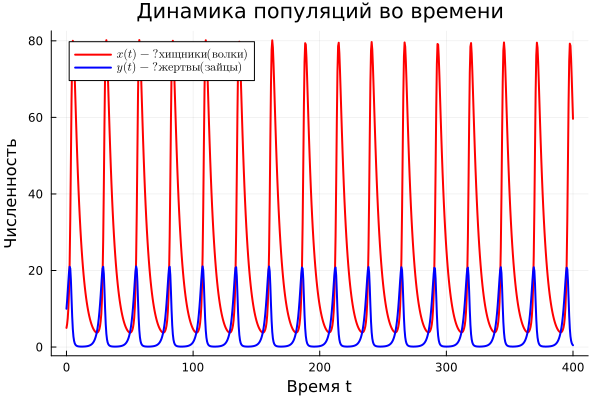

In [20]:
plot_time = plot(t_vals, x_vals, label=L"x(t) - \text{хищники (волки)}",
                 xlabel="Время t", ylabel="Численность",
                 title="Динамика популяций во времени",
                 linewidth=2, color=:red)
plot!(plot_time, t_vals, y_vals, label=L"y(t) - \text{жертвы (зайцы)}",
      linewidth=2, color=:blue)

График 2: Фазовый портрет (зависимость x от y)

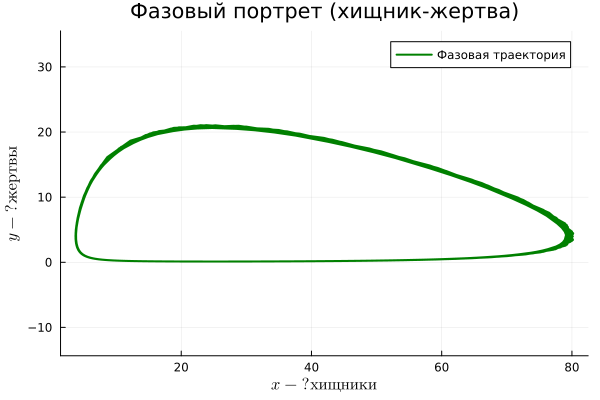

In [22]:
plot_phase = plot(x_vals, y_vals, label="Фазовая траектория",
                  xlabel=L"x - \text{хищники}",
                  ylabel=L"y - \text{жертвы}",
                  title="Фазовый портрет (хищник-жертва)",
                  linewidth=2, color=:green, aspect_ratio=:equal)

Добавляем стационарную точку на фазовый портрет
Стационарное состояние: x₀ = c/d, y₀ = a/b

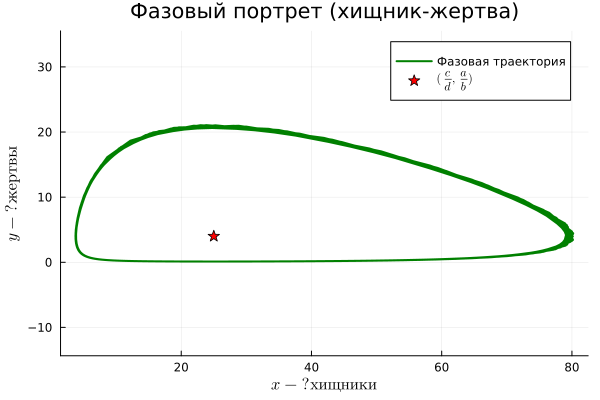

In [24]:
x_stationary = c / d
y_stationary = a / b
scatter!(plot_phase, [x_stationary], [y_stationary],
         label=L"(\frac{c}{d}, \frac{a}{b})",
         color=:red, markersize=6, marker=:star)

Отображение графиков

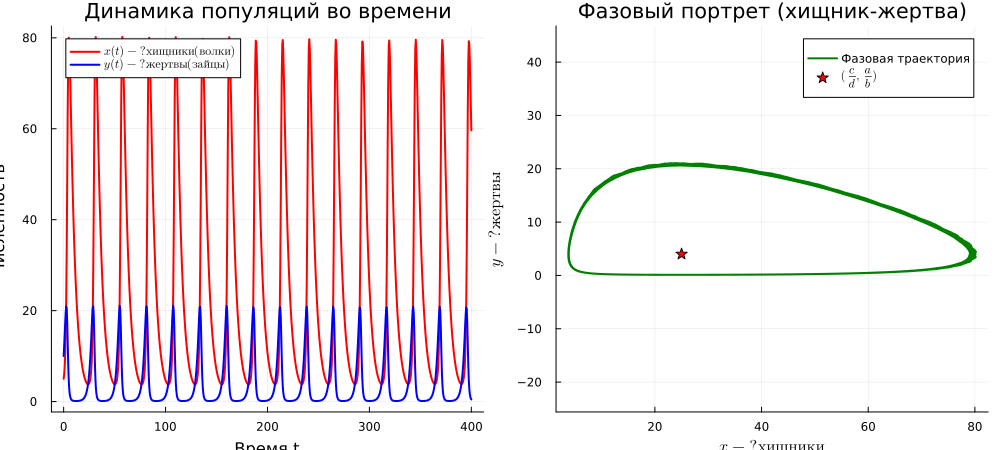

In [26]:
display(plot(plot_time, plot_phase, layout=(1,2), size=(1000,450)))

============================================================================
Задание 2: Нахождение стационарного состояния системы
============================================================================

In [28]:
println("\n" * "="^60)
println("Задание 2: Стационарное состояние системы")
println("="^60)

println("\nИсходная система:")
println("dx/dt = -a·x + b·x·y = x·(-a + b·y)")
println("dy/dt =  c·y - d·x·y = y·(c - d·x)")

println("\nДля стационарного состояния: dx/dt = 0, dy/dt = 0")
println("x·(-a + b·y) = 0")
println("y·(c - d·x) = 0")

println("\nНетривиальное решение (x ≠ 0, y ≠ 0):")
println("-a + b·y = 0  →  y = a/b")
println(" c - d·x = 0  →  x = c/d")

println("\nПараметры модели:")
println("a = $a  (смертность хищников)")
println("b = $b  (прирост хищников)")
println("c = $c  (прирост жертв)")
println("d = $d  (смертность жертв)")

x0 = c / d
y0 = a / b

println("\nСтационарная точка:")
println("x₀ = c/d = $c / $d = $x0")
println("y₀ = a/b = $a / $b = $y0")

println("\nТривиальное решение (x = 0, y = 0): вымирание обоих видов")
println("Решение (x = c/d, y = a/b): сосуществование видов в равновесии")


Задание 2: Стационарное состояние системы

Исходная система:
dx/dt = -a·x + b·x·y = x·(-a + b·y)
dy/dt =  c·y - d·x·y = y·(c - d·x)

Для стационарного состояния: dx/dt = 0, dy/dt = 0
x·(-a + b·y) = 0
y·(c - d·x) = 0

Нетривиальное решение (x ≠ 0, y ≠ 0):
-a + b·y = 0  →  y = a/b
 c - d·x = 0  →  x = c/d

Параметры модели:
a = 0.2  (смертность хищников)
b = 0.05  (прирост хищников)
c = 0.5  (прирост жертв)
d = 0.02  (смертность жертв)

Стационарная точка:
x₀ = c/d = 0.5 / 0.02 = 25.0
y₀ = a/b = 0.2 / 0.05 = 4.0

Тривиальное решение (x = 0, y = 0): вымирание обоих видов
Решение (x = c/d, y = a/b): сосуществование видов в равновесии


============================================================================
Дополнительный анализ: влияние начальных условий
============================================================================

In [30]:
println("\n" * "="^60)
println("Дополнительный анализ: исследование различных начальных условий")
println("="^60)


Дополнительный анализ: исследование различных начальных условий


Исследуем разные начальные условия

In [32]:
initial_conditions = [
    [2.0, 5.0],    # мало хищников, мало жертв
    [5.0, 10.0],   # средние значения (исходные)
    [8.0, 20.0],   # много хищников, много жертв
    [10.0, 3.0]    # много хищников, мало жертв
]

labels = ["(x₀=2, y₀=5)", "(x₀=5, y₀=10)", "(x₀=8, y₀=20)", "(x₀=10, y₀=3)"]
colors = [:blue, :green, :orange, :purple]

plot_phase_multi = plot(title="Фазовые портреты при разных начальных условиях",
                        xlabel=L"x - \text{хищники}",
                        ylabel=L"y - \text{жертвы}",
                        aspect_ratio=:equal)

for (ic, label, color) in zip(initial_conditions, labels, colors)
    prob_ic = ODEProblem(predator_prey!, ic, tspan, params)
    sol_ic = solve(prob_ic, saveat=0.5)
    x_ic = [u[1] for u in sol_ic.u]
    y_ic = [u[2] for u in sol_ic.u]
    plot!(plot_phase_multi, x_ic, y_ic, label=label, linewidth=1.5, color=color)
end

Стационарная точка

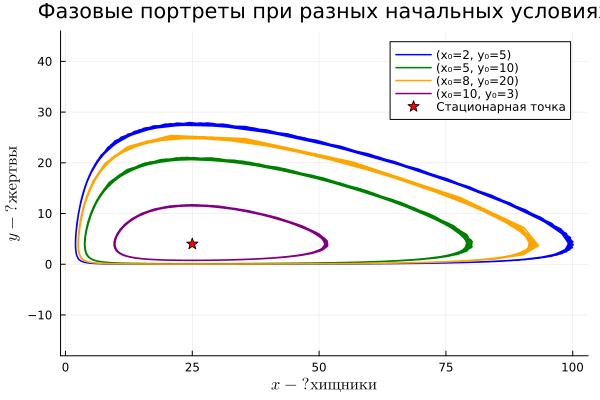

In [34]:
scatter!(plot_phase_multi, [x_stationary], [y_stationary],
         label="Стационарная точка", color=:red, markersize=6, marker=:star)

display(plot_phase_multi)

============================================================================
Вывод информации о модели
============================================================================

In [36]:
println("\n" * "="^60)
println("Анализ модели Лотки-Вольтерры")
println("="^60)

println("\nХарактеристики модели:")
println("• Модель описывает циклические колебания численности хищников и жертв")
println("• Колебания происходят в противофазе: максимуму хищников соответствует минимум жертв")
println("• Амплитуда колебаний зависит от начальных условий")
println("• Стационарная точка является центром (устойчиво по Ляпунову, но не асимптотически)")
println("• Система является консервативной (имеет первый интеграл)")

println("\nФизический смысл параметров:")
println("• a = $a — коэффициент смертности хищников в отсутствие пищи")
println("• b = $b — эффективность перехода биомассы жертв в биомассу хищников")
println("• c = $c — коэффициент рождаемости жертв")
println("• d = $d — эффективность охоты хищников")

println("\nСтационарное состояние системы: (x₀, y₀) = ($x_stationary, $y_stationary)")
println("При этом начальные условия:")
for (ic, label) in zip(initial_conditions, labels)
    println("  $label → x₀=$(ic[1]), y₀=$(ic[2])")
end


Анализ модели Лотки-Вольтерры

Характеристики модели:
• Модель описывает циклические колебания численности хищников и жертв
• Колебания происходят в противофазе: максимуму хищников соответствует минимум жертв
• Амплитуда колебаний зависит от начальных условий
• Стационарная точка является центром (устойчиво по Ляпунову, но не асимптотически)
• Система является консервативной (имеет первый интеграл)

Физический смысл параметров:
• a = 0.2 — коэффициент смертности хищников в отсутствие пищи
• b = 0.05 — эффективность перехода биомассы жертв в биомассу хищников
• c = 0.5 — коэффициент рождаемости жертв
• d = 0.02 — эффективность охоты хищников

Стационарное состояние системы: (x₀, y₀) = (25.0, 4.0)
При этом начальные условия:
  (x₀=2, y₀=5) → x₀=2.0, y₀=5.0
  (x₀=5, y₀=10) → x₀=5.0, y₀=10.0
  (x₀=8, y₀=20) → x₀=8.0, y₀=20.0
  (x₀=10, y₀=3) → x₀=10.0, y₀=3.0
